## 5. Método de Euler para EDOs de 1ª ordem

### 5.1 Introdução

No Notebook 4 resolvemos EDOs de 1ª ordem de forma **analítica**, obtendo uma
expressão fechada para a solução. Muitas equações de interesse prático, porém,
não têm solução analítica conhecida. Nesses casos recorremos a **métodos
numéricos**, que constroem uma aproximação da solução em um conjunto discreto de
pontos.

Neste notebook estudamos o **método de Euler**, o mais simples desses métodos,
aplicado a problemas de valor inicial (PVI) de 1ª ordem:

$$
\begin{cases}
\dfrac{dy}{dx} = f(x,y)\\
\\
y(x_0) = y_0
\end{cases}
$$

**Recordando a derivada numérica.** Como visto no Notebook 3, a derivada de uma
função $y = f(x)$ em um ponto $x_i$ pode ser aproximada por diferenças finitas,
estimando a inclinação da função a partir de valores na vizinhança do ponto:

- _para frente_:&nbsp; $f'(x_i) \approx \dfrac{f(x_{i+1}) - f(x_i)}{h}$
- _para trás_:&nbsp; $f'(x_i) \approx \dfrac{f(x_i) - f(x_{i-1})}{h}$
- _central_:&nbsp; $f'(x_i) \approx \dfrac{f(x_{i+1}) - f(x_{i-1})}{2h}$

sendo $h$ o espaçamento entre os pontos.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_III/refs/heads/main/Notebook%2005%20-%20M%C3%A9todo%20de%20Euler%20para%20EDOs%20de%201%C2%AA%20ordem/imagens/diffs.png" width="960">

O método de Euler se apoia na diferença **para frente**. Ela pode ser obtida da
série de Taylor de $f$ desenvolvida em torno de $x_i$:

$$f(x_{i+1}) = f(x_i) + f'(x_i)\,h + f''(x_i)\frac{h^2}{2!}
              + f'''(x_i)\frac{h^3}{3!} + \cdots$$

Isolando $f'(x_i)$ e desprezando os termos a partir de $h^2$, obtemos

$$f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{h}$$

com **erro de truncamento** proporcional a $h$, ou seja, $O(h)$. Quanto menor o
passo $h$, menor o erro, mas maior o esforço computacional, o que impossibilita
o cálculo com valores de $h$ próximos de zero. Esse compromisso é retomado na
Seção 5.4.

### 5.2 A ideia do método: campo de direções e diferença para frente

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4, 3)

**Exemplo 5.1:** A equação diferencial $\frac{du}{dt} = t + 2$ tem solução
$u(t) = \frac{t^2}{2} + 2t + c$ obtida facilmente por integração. 

Nesse exemplo, as soluções para alguns valores de $c$, uma solução particular e um campo de direções serão ilustrados por meio de seus gráficos.

Se impormos uma condição inicial, como por exemplo $u(0)= 8$, obtemos o valor
$c=8$, o que restringe a solução a uma única curva e não mais a uma família de
curvas. Uma equação diferencial acompanhada de uma condição inicial como essa
compõe o que chamamos de um *problema de valor inicial* (PVI).

Ou seja, o problema de valor inicial descrito acima pode ser enunciado como

$$
\begin{cases}
\frac {du}{dt}= t+2\\
\\
u(0)=8
\end{cases}$$

Além disso, se pensarmos nas direções tangentes às curvas-solução em um conjunto de pontos
distribuídos no plano temos o que chamamos de **campo de direções** ou **campo de
inclinações**. Como a inclinação de uma curva $y$ em um determinado ponto é dada
pela sua derivada $y'$ nesse ponto, podemos construir o campo de direções para
uma EDO mesmo não tendo encontrado solução alguma. 

Abaixo são mostrados, lado a lado, a família de soluções para diferentes valores de $c$ com a solução particular do PVI ($u(0)=8$) destacada, e o campo de direções da EDO do Exemplo 5.1 com essa mesma solução particular sobreposta.

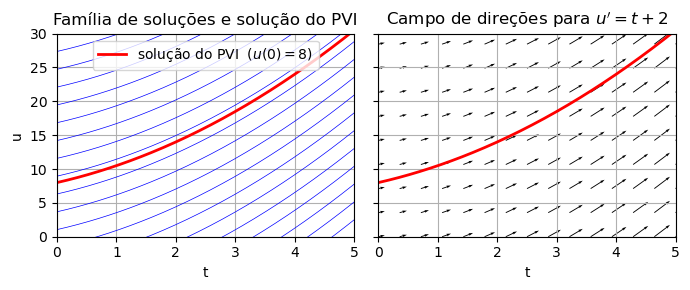

In [2]:
# definindo a figura e para dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,3), sharey=True)
for ax in (ax1, ax2):
    ax.set_xlim(0, 5)
    ax.set_ylim(0,30)

# escrevendo a solução geral e a discretização de t
ti = np.linspace(0, 5, 200)
u  = lambda t, c: t**2/2 + 2*t + c        

# painel esquerdo: família de soluções + solução do PVI
for c in np.linspace(-20, 30, 20):
    ax1.plot(ti, u(ti, c), 'b', lw=0.5)
# plota
ax1.plot(ti, u(ti, 8), 'r', lw=2, label='solução do PVI  ($u(0)=8$)')
ax1.set_title("Família de soluções e solução do PVI")
ax1.set_xlabel("t"); ax1.set_ylabel("u")
ax1.legend(loc="upper center")
ax1.grid()

# escrevendo a inclinação du e a discretização da malha 2d (txu)
tt, uu = np.meshgrid(np.linspace(0, 5, 15),
                     np.linspace(0, 32, 10))
du = tt + 2

# painel direito: campo de direções + solução do PVI
ax2.quiver(tt, uu, np.ones(tt.shape), du, width=0.003, angles='xy')
# plota
ax2.plot(ti, u(ti, 8), 'r', lw=2)
ax2.set_title("Campo de direções para $u' = t + 2$")
ax2.set_xlabel("t")
ax2.grid()

# define layout e mostra
plt.tight_layout()
plt.show()

Observe que, tomando a fórmula de diferenças finitas para frente, podemos escrever

$$f(x_{i+1}) =  f(x_i) + f'(x_i)h$$

ou ainda

$$y_{i+1} =  y_i + \frac{dy}{dx}(x_i,y_i)\,h$$

Então, tomando $u_0=8$ e $\frac{du}{dt}(t)=t+2$ do Exemplo 5.1, podemos escrever
uma fórmula para obter aproximações para pontos da solução particular fazendo:

$$u_{i+1} =  u_i + \frac{du}{dt}(t_i, u_i)\,h$$

ou

$$u_{i+1} =  u_i + (t_i + 2)\,h$$

Assim, escolhendo $h=0,5$ obtemos as soluções aproximadas:

$u_1 = u_0 + (t_0+2)\,0,5 = 8 + (0+2)\,0,5 = 9$

$u_2 = u_1 + (t_1+2)\,0,5 = 9 + (0,5+2)\,0,5= 10,25$

$u_3 = u_2 + (t_2+2)\,0,5 = 10,25 + (1+2)\,0,5= 11,75$

$\vdots$

Vamos fazer as contas em Python, avançando de $t=0$ até $t=5$. Note que, a cada
linha, comparamos a aproximação $u_{i+1}$ com o valor **exato**
$u(t_{i+1}) = \frac{t_{i+1}^2}{2} + 2t_{i+1} + 8$ no mesmo ponto:

In [3]:
u = 8.0
t = 0.0
h = 0.5
ue = lambda t: t**2/2 + 2*t + 8      # solução exata do PVI
ua = [8]

print(f"{'t':>5}{'Euler':>12}{'Exata':>12}{'Erro':>12}")
print(f"{t:5.1f}{u:12.4f}{ue(t):12.4f}{u - ue(t):12.4f}")
for _ in range(10):
    u = u + (t + 2)*h                # passo de Euler
    ua.append(u)
    t = t + h
    print(f"{t:5.1f}{u:12.4f}{ue(t):12.4f}{u - ue(t):12.4f}")

    t       Euler       Exata        Erro
  0.0      8.0000      8.0000      0.0000
  0.5      9.0000      9.1250     -0.1250
  1.0     10.2500     10.5000     -0.2500
  1.5     11.7500     12.1250     -0.3750
  2.0     13.5000     14.0000     -0.5000
  2.5     15.5000     16.1250     -0.6250
  3.0     17.7500     18.5000     -0.7500
  3.5     20.2500     21.1250     -0.8750
  4.0     23.0000     24.0000     -1.0000
  4.5     26.0000     27.1250     -1.1250
  5.0     29.2500     30.5000     -1.2500


O método mostrado nesse exemplo chama-se **método de Euler** e é usado para obter
soluções numéricas de problemas de valor inicial.

Agora vamos plotar as soluções exata e aproximada juntamente com algumas outras soluções que poderiam ser obtidas a partir de diferentes condições iniciais para obter uma visão geral do problema.

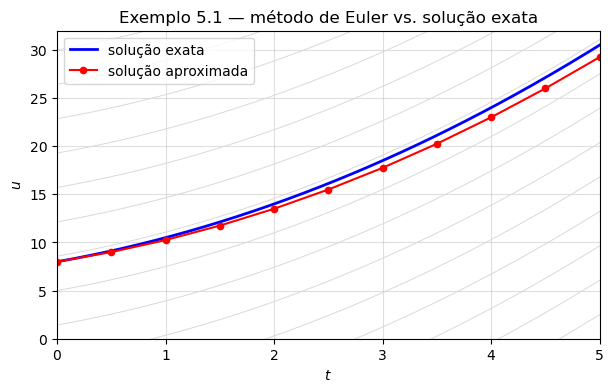

In [4]:
ti = np.linspace(0, 5, 11)      
tt = np.linspace(0, 5, 200)     
u  = lambda t, c: t**2/2 + 2*t + c       

plt.figure(figsize=(7, 4))

# família de soluções ao fundo (um c para cada curva)
for c in np.linspace(-20, 30, 15):
    plt.plot(tt, u(tt, c), color='0.85', lw=0.7)

# solução exata do PVI (c = 8) e aproximação pelo método de Euler
plt.plot(tt, u(tt, 8), 'b-',  lw=2,          label='solução exata')
plt.plot(ti, ua,       'r.-', lw=1.5, ms=9,  label='solução aproximada')

plt.title("Exemplo 5.1 — método de Euler vs. solução exata")
plt.xlabel("$t$"); plt.ylabel("$u$")
plt.xlim(0, 5); plt.ylim(0, 32)
plt.legend(loc="upper left")
plt.grid(alpha=0.4)
plt.show()

**Conclusão:** A tabela e o gráfico mostram que a aproximação
pelo método de Euler acompanha a forma da solução exata, mas fica
**sistematicamente abaixo** dela: o erro é de $0,125$ em $t = 0,5$ e cresce de
forma regular até $1,25$ em $t = 5$ (cerca de $4\%$ do valor exato).

Esse comportamento é típico do método:

- Como a solução é **convexa** ($u'' = 1 > 0$), cada passo segue a reta tangente
  no início do subintervalo, que passa por baixo da curva. Todos os erros têm o
  mesmo sinal e se **acumulam**, em vez de se cancelar.
- Aqui $u''$ é constante, então cada passo introduz exatamente o mesmo erro local
  $\tfrac{u''}{2}h^2 = \tfrac{1}{2}(0,5)^2 = 0,125$. Depois de $n$ passos o erro
  acumulado é $0,125\,n = 0,25\,t$, ou seja,cresce linearmente com $t$ e com $h$.

Reduzir o passo diminui o erro (com $h = 0,25$ o erro em $t = 5$ cairia para
aproximadamente a metade). Essa relação entre o erro e o passo $h$ é retomada,
de forma mais geral, na Seção 5.4.

### 5.3 Solução numérica de um PVI: método de Euler

Um Problema de Valor Inicial (PVI) de primeira ordem consiste de
uma equação diferencial $y' = f(x,y)$, $x \geq x_0$, e uma condição inicial
$y(x_0) = y_0$, em que $y_0$ é um valor dado, chamado de valor inicial.

Neste caso, podemos escrever o PVI da seguinte forma:

$$
\begin{cases}
y'= f(x,y)\\
\\
y(x_0)=y_0
\end{cases}$$

Resolver o PVI consiste em determinar uma função $y(x)$ que satisfaça a equação
diferencial $y' = f(x,y)$ e a condição inicial $y(x_0) = y_0$. Se $f$ e
$\frac{\partial f}{\partial y}$ são contínuas, o PVI apresenta solução única.

Resolver numericamente um PVI consiste em calcular aproximações para $y = y(x)$ em pontos discretos $x_0,x_1,x_2,\dots,x_N$ de um intervalo $[a,b]$.

Vamos agora estudar a solução de equações diferenciais ordinárias da forma

$$ \frac{dy}{dx} = f(x,y) $$

usando um método numérico de _passo único_, denominado **método de Euler**, em que obtemos um processo iterativo
para a solução em cada ponto $y_{i+1}$ a partir de um ponto $y_i$ conhecido.
Fazemos isso considerando a derivada no ponto $x_i$ para obter o valor da função
no ponto $x_{i+1}$, sendo o tamanho de cada _passo_ dado por
$h = x_{i+1} - x_i$. Matematicamente, escrevemos

$$ y_{i+1} = y_i + \phi\, h$$

Assim, a estimativa da inclinação $\phi$ é usada para extrapolar de um valor
antigo $y_i$ para um valor novo $y_{i+1}$ em uma distância $h$
([Chapra e Canale, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788580555691/pageid/642)).

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_III/refs/heads/main/Notebook%2005%20-%20M%C3%A9todo%20de%20Euler%20para%20EDOs%20de%201%C2%AA%20ordem/imagens/euler_fig01.png" width="400">

A inclinação no início do intervalo é tomada como uma aproximação da inclinação
média em todo o intervalo, e com isso um erro é inserido. Em geral, quanto maior
o tamanho do passo, maior é o erro nessa aproximação.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_III/refs/heads/main/Notebook%2005%20-%20M%C3%A9todo%20de%20Euler%20para%20EDOs%20de%201%C2%AA%20ordem/imagens/euler_fig02.png" width="400">

No método de Euler a inclinação é tomada como sendo a derivada primeira da função
$f(x,y)$, ou seja, considerando que $\frac{dy}{dx} = f(x,y)$, escrevemos

$$ y_{i+1} = y_i + f(x_i, y_i)\, h$$

Assim, a partir de um valor inicial $y_0$ conhecido, obtemos estimativas para os
valores subsequentes $y_1, y_2, y_3, \dots$ da função. Esse método também é
chamado de método de _Euler-Cauchy_ ou _ponto-inclinação_.

O método de Euler é considerado de baixa precisão, e por isso é raramente usado em situações reais mas, devido à sua simplicidade, ele explica bem o princípio dos métodos baseados na série de Taylor.

#### Uma função reutilizável para o método de Euler

Para não reescrever o laço a cada exemplo, vamos implementar o método de Euler em
uma função reutilizável. Ela recebe a função $f(x,y)$, o ponto inicial
$(x_0, y_0)$, o passo $h$ e o número de passos $N$, e devolve os vetores com os
pontos $x_i$ e as aproximações $y_i$.

In [5]:
def euler(f, x0, y0, h, N):
    """Método de Euler para o PVI  y' = f(x, y),  y(x0) = y0.

    Retorna dois vetores (x, y) com N + 1 pontos, de x0 até x0 + N*h.
    """
    x = np.zeros(N + 1)
    y = np.zeros(N + 1)
    x[0], y[0] = x0, y0
    for i in range(N):
        x[i + 1] = x[i] + h
        y[i + 1] = y[i] + f(x[i], y[i]) * h
    return x, y

**Exemplo 5.2:** Use o método de Euler para integrar numericamente a equação

$$ \frac{dy}{dx} = -2x^3+12x^2-20x+8{,}5$$

de $x = 0$ a $x = 4$ com um tamanho de passo de $0{,}5$. A condição inicial em
$x = 0$ é $y = 1$.

A solução exata é dada por $y = -0{,}5x^4+4x^3-10x^2+8{,}5x+1$.

_Solução:_ com um passo $h=0{,}5$, temos $x_0 = 0{,}0$, $x_1 = 0{,}5$,
$x_2 = 1{,}0$, $x_3 = 1{,}5$, ..., $x_8 = 4{,}0$. Assim, a partir da equação

$$ y_{i+1} = y_i + f(x_i, y_i)\, h$$

com

$$f(x,y)= \frac{dy}{dx} = -2x^3+12x^2-20x+8{,}5$$

e sabendo que em $x_0 = 0$ temos $y_0 = 1$, obtemos os valores de
$y_1, y_2, y_3, \dots, y_8$. Vamos fazer isso computacionalmente, usando a função
`euler` definida acima.

In [6]:
f  = lambda x, y: -2*x**3 + 12*x**2 - 20*x + 8.5          # dy/dx = f(x, y)
ye = lambda x: -0.5*x**4 + 4*x**3 - 10*x**2 + 8.5*x + 1.0  # solução exata

x, y = euler(f, x0=0.0, y0=1.0, h=0.5, N=8)
print("xi:", x)
print("yi:", np.round(y, 4))

xi: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4. ]
yi: [1.    5.25  5.875 5.125 4.5   4.75  5.875 7.125 7.   ]


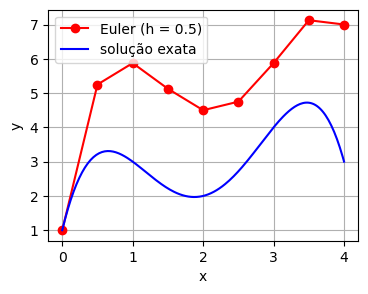

In [7]:
xe = np.linspace(0, 4, 200)

plt.plot(x, y, "ro-", label="Euler (h = 0.5)")
plt.plot(xe, ye(xe), "b-", label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Como a solução exata é conhecida, podemos montar uma tabela comparando, ponto a
ponto, a aproximação de Euler com o valor exato:

In [8]:
print(f"{'x':>5}{'Euler':>12}{'Exata':>12}{'Erro':>12}")
for xi, yi in zip(x, y):
    print(f"{xi:5.1f}{yi:12.5f}{ye(xi):12.5f}{yi - ye(xi):12.5f}")

    x       Euler       Exata        Erro
  0.0     1.00000     1.00000     0.00000
  0.5     5.25000     3.21875     2.03125
  1.0     5.87500     3.00000     2.87500
  1.5     5.12500     2.21875     2.90625
  2.0     4.50000     2.00000     2.50000
  2.5     4.75000     2.71875     2.03125
  3.0     5.87500     4.00000     1.87500
  3.5     7.12500     4.71875     2.40625
  4.0     7.00000     3.00000     4.00000


O erro cresce à medida que avançamos no intervalo, pois cada passo parte de um
valor que já é aproximado — os erros se acumulam. Na Seção 5.4 investigamos como
esse erro diminui quando reduzimos o passo $h$.

Nesse exemplo a EDO depende apenas de $x$, isto é, $\frac{dy}{dx} = f(x)$. Um caso
mais geral envolve EDOs que dependem de $x$ **e** de $y$,

$$\frac{dy}{dx} = f(x,y),$$

como o do próximo exemplo. Daqui em diante nossos exemplos passam a envolver cada
vez mais esse caso geral.

**Exemplo 5.3:** Use o método de Euler para integrar numericamente a equação

$$ \frac{dy}{dx} = x-y+2$$

de $x = 0$ a $x = 1$ com um tamanho de passo de $0{,}25$. A condição inicial em
$x = 0$ é $y = 2$. A solução exata é $y(x) = e^{-x} + x + 1$.

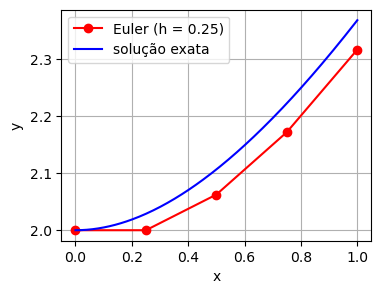

erro em x = 1: 0.05147


In [9]:
f  = lambda x, y: x - y + 2            # dy/dx = f(x, y)
ye = lambda x: np.exp(-x) + x + 1      # solução exata (y(0) = 2)

x, y = euler(f, x0=0.0, y0=2.0, h=0.25, N=4)

xe = np.linspace(0, 1, 200)
plt.plot(x, y, "ro-", label="Euler (h = 0.25)")
plt.plot(xe, ye(xe), "b-", label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

print(f"erro em x = 1: {abs(y[-1] - ye(x[-1])):.5f}")

#### Atividade 5.1

Refaça o Exemplo 5.2 com os passos $h = 0{,}25$ e $h = 0{,}1$. Monte a tabela de
erros nos dois casos e compare o erro final ($x = 4$) com o obtido usando
$h = 0{,}5$.

#### Atividade 5.2

Considere o PVI $y' = y - x$, $y(0) = 2$, em $[0, 1]$, cuja solução exata é
$y(x) = x + 1 + e^{x}$. Aplique o método de Euler com $h = 0{,}25$, plote a
solução aproximada junto com a exata e comente o comportamento do erro ao longo
do intervalo.

### 5.4 O erro do método de Euler e o efeito do passo $h$

A cada passo, o método de Euler comete um **erro de truncamento local**
proporcional a $h^2$ (o primeiro termo desprezado na série de Taylor). Como o
número de passos necessários para percorrer um intervalo fixo é proporcional a
$1/h$, esses erros se acumulam e o **erro global** ao final do intervalo acaba
proporcional a $h$. Por isso dizemos que o método de Euler é de **primeira
ordem**: ao dividir o passo por 2, espera-se que o erro final também caia,
aproximadamente, pela metade.

Vamos verificar isso com a EDO do Exemplo 5.2, cuja solução exata conhecemos.

In [10]:
f  = lambda x, y: -2*x**3 + 12*x**2 - 20*x + 8.5
ye = lambda x: -0.5*x**4 + 4*x**3 - 10*x**2 + 8.5*x + 1.0

hs = np.array([0.5, 0.25, 0.125, 0.0625, 0.03125])
erros = np.zeros(len(hs))

print(f"{'h':>9}{'erro em x=4':>16}{'razão':>9}")
for k, h in enumerate(hs):
    N = round(4.0 / h)
    x, y = euler(f, 0.0, 1.0, h, N)
    erros[k] = abs(y[-1] - ye(x[-1]))
    razao = "-" if k == 0 else f"{erros[k-1] / erros[k]:.2f}"
    print(f"{h:9.5f}{erros[k]:16.6f}{razao:>9}")

        h     erro em x=4    razão
  0.50000        4.000000        -
  0.25000        2.000000     2.00
  0.12500        1.000000     2.00
  0.06250        0.500000     2.00
  0.03125        0.250000     2.00


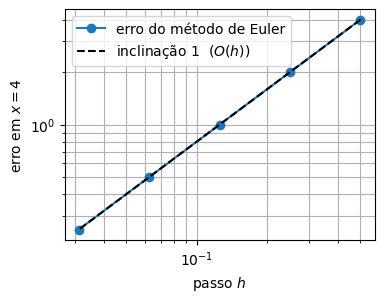

In [11]:
plt.loglog(hs, erros, "o-", label="erro do método de Euler")
plt.loglog(hs, erros[0]*(hs/hs[0]), "k--", label="inclinação 1  ($O(h)$)")
plt.xlabel("passo $h$"); plt.ylabel("erro em $x = 4$")
plt.legend(); plt.grid(True, which="both")
plt.show()

A coluna *razão* fica próxima de 2: cada vez que o passo é reduzido à metade, o
erro final também cai, aproximadamente, à metade. No gráfico log-log os pontos se
alinham a uma reta de inclinação 1, confirmando que o erro global do método de
Euler é $O(h)$.

#### Atividade 5.3

Repita o estudo de erro acima para o PVI do Exemplo 5.3. A razão entre erros
sucessivos também se aproxima de 2? Refaça ainda para a EDO $y' = y$, $y(0) = 1$
em $[0, 1]$ (solução exata $y = e^x$).

### 5.5 Solução numérica de um PVI com SciPy

Usando a biblioteca `scipy` podemos obter uma solução numérica para um PVI com a
função `solve_ivp`. Ela emprega métodos mais precisos que o de Euler; vamos usá-la
como referência para comparar com a nossa implementação. Primeiro importamos a
função do módulo `integrate`:

In [12]:
from scipy.integrate import solve_ivp

Vamos resolver o mesmo PVI do Exemplo 5.3, $y' = x - y + 2$ com $y(0) = 2$, em
$[0, 1]$. A função passada para `solve_ivp` recebe o vetor de estado `y`, por isso
usamos `y[0]`.

In [13]:
def du(x, y):
    return x - y[0] + 2

I  = (0.0, 1.0)
xx = np.linspace(I[0], I[1], 50)

sol = solve_ivp(du, I, [2.0], t_eval=xx)
print(np.round(sol.y, 4))

[[2.     2.0002 2.0008 2.0018 2.0032 2.005  2.0072 2.0097 2.0126 2.0158
  2.0194 2.0233 2.0276 2.0321 2.037  2.0422 2.0477 2.0535 2.0596 2.066
  2.0727 2.0797 2.0869 2.0944 2.1022 2.1102 2.1185 2.127  2.1358 2.1448
  2.1541 2.1636 2.1733 2.1832 2.1933 2.2037 2.2142 2.225  2.2359 2.2471
  2.2584 2.2699 2.2816 2.2935 2.3055 2.3177 2.3301 2.3426 2.3552 2.3681]]


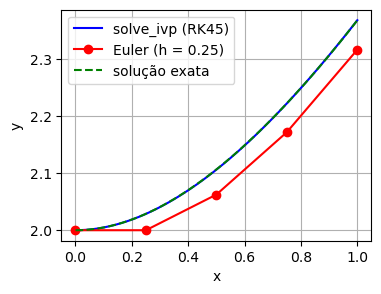

In [14]:
ye = lambda x: np.exp(-x) + x + 1
xe_, ye_ = euler(lambda x, y: x - y + 2, 0.0, 2.0, 0.25, 4)

plt.plot(sol.t, sol.y[0], "b-", label="solve_ivp (RK45)")
plt.plot(xe_, ye_, "ro-", label="Euler (h = 0.25)")
plt.plot(xx, ye(xx), "g--", label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

O método usado por padrão na função `solve_ivp` é o `RK45`, ou seja, o método de
Runge-Kutta explícito de ordem 5(4). O erro é controlado assumindo a precisão do
método de quarta ordem, mas os passos são executados usando a fórmula precisa de
quinta ordem. Mais informações sobre os outros métodos disponíveis e sua descrição
podem ser acessadas em:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

### 5.6 Combinando solução analítica e numérica

**Exemplo 5.4:** vamos obter a solução da equação $y' + y = \cos(t)$ com a
condição inicial $y(0) = 1$, comparando a solução analítica (obtida com SymPy,
como no Notebook 4) com a aproximação do método de Euler, sobre o campo de
direções.

In [15]:
import sympy as sp

In [16]:
t, C1 = sp.symbols('t, C1')
y = sp.Function('y')

eq = sp.Eq(y(t).diff(t)+y(t), sp.cos(t))
sol = sp.dsolve(eq, ics={y(0): 1})
display(sol)

Eq(y(t), sin(t)/2 + cos(t)/2 + exp(-t)/2)

Agora plotamos a solução particular, a aproximação do método de Euler e o campo de
direções.

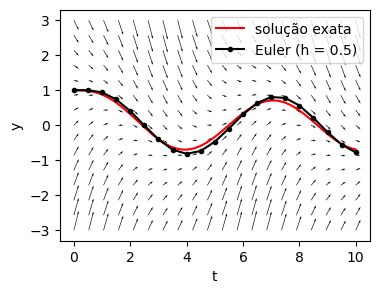

In [17]:
t = np.linspace(0, 10, 20)
y = np.linspace(-3, 3, 15)

tt, yy = np.meshgrid(t, y)
dy = -yy + np.cos(tt)
plt.quiver(tt, yy, np.ones(dy.shape), dy, width=0.002)

# solução exata
ti = np.linspace(0, 10, 200)
plt.plot(ti, np.cos(ti)/2 + np.sin(ti)/2 + 0.5*np.exp(-ti), "r", label="solução exata")

# aproximação pelo método de Euler
f = lambda t, y: -y + np.cos(t)
te, ye_ = euler(f, 0.0, 1.0, 0.5, 20)
plt.plot(te, ye_, "k.-", label="Euler (h = 0.5)")

plt.legend(); plt.xlabel("t"); plt.ylabel("y")
plt.show()

### 5.7 Exercícios

**1.** Resolva o seguinte problema de valor inicial no intervalo de $t=0$ a $2$,
com $y(0)=1$, analiticamente e numericamente, usando o método de Euler
($h=0,5$ e $0,25$), e plote as soluções.
$$
\frac{d y}{d t}=y t^2-1,1 y
$$

**2.** Resolva o seguinte problema de valor inicial no intervalo de $t=0$ a $1$,
com $y(0)=1$, analiticamente e numericamente, usando o método de Euler
($h=0,5$ e $0,25$), e plote as soluções.
$$
\frac{d y}{d t}=(1+4 t) \sqrt{y}
$$

**3.** Usando o método de Euler, determine uma solução aproximada para o PVI dado
por

$$ \begin{cases}
y'= -3y+6x+5 \\
y(0)=3
\end{cases}$$

com $x \in [0,1]$ e $N=10$. Compare com a solução exata $y(x)=2e^{-3x}+2x+1$.

**4.** Dado o PVI abaixo e a sua solução exata, use dois métodos diferentes para
estimar $u(t)$ com o passo sugerido, plote e comente os resultados.

$$ \begin{cases}
u'= t^2(5-u)\\
0 \leq t \leq 2 \\
u(0)=0
\end{cases}$$

Solução exata: $u(t)=5-5e^{-t^3/3}$. Use passo $h=0,25$ e também $h=0,1$.

**5.** Use o método de Euler para obter uma aproximação para as soluções de cada
um dos seguintes problemas de valor inicial.

a. $y^{\prime}=t e^{3 t}-2 y, \quad 0 \leq t \leq 1, \quad y(0)=0, \quad$ com $h=0,5$

b. $y^{\prime}=1+(t-y)^2, \quad 2 \leq t \leq 3, \quad y(2)=1, \quad$ com $h=0,5$

c. $y^{\prime}=1+y / t, \quad 1 \leq t \leq 2, \quad y(1)=2, \quad$ com $h=0,25$

d. $y^{\prime}=\cos 2 t+\operatorname{sen} 3 t, \quad 0 \leq t \leq 1, \quad y(0)=1, \quad$ com $h=0,25$

**6.** Use o método de Euler para obter uma aproximação para as soluções de cada
um dos seguintes problemas de valor inicial.

a. $y^{\prime}=e^{t-y}, \quad 0 \leq t \leq 1, \quad y(0)=1, \quad$ com $h=0,5$

b. $y^{\prime}=\frac{1+t}{1+y}, \quad 1 \leq t \leq 2, \quad y(1)=2, \quad$ com $h=0,5$

c. $y^{\prime}=-y+t y^{1 / 2}, \quad 2 \leq t \leq 3, \quad y(2)=2, \quad$ com $h=0,25$

d. $y^{\prime}=t^{-2}(\operatorname{sen} 2 t-2 t y), \quad 1 \leq t \leq 2, \quad y(1)=2, \quad$ com $h=0,25$

**Referências**

ARENALES, Selma; DAREZZO, Artur. Cálculo Numérico: aprendizagem com Apoio de Software. Porto Alegre: Cengage Learning Brasil, 2016.

BOYCE, William E. Equações Diferenciais Elementares e Problemas de Valores de Contorno. Barueri: Grupo GEN, 2020.

BURDEN, Richard L.; FAIRES, J D.; BURDEN, Annette M. Análise Numérica - Tradução da 10ª edição norte-americana. 3. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2016.

CHAPRA, Steven C.; CANALE, Raymond P. Métodos numéricos para engenharia. Porto Alegre: Grupo A, 2016.